# 🚗 Driver Behavior Anomaly Detection
## Notebook 05 — Model Building & Training (Steps 7 & 8)

### Recommended Architecture: CNN-LSTM Hybrid

```
Input (50 timesteps × 11 features)
    ↓
Conv1D  →  BatchNorm  →  MaxPool       ← Extracts local patterns (spikes, peaks)
    ↓
Conv1D  →  BatchNorm  →  MaxPool       ← Extracts higher-level patterns
    ↓
LSTM  →  LSTM                          ← Captures how patterns evolve over time
    ↓
Dense  →  BatchNorm  →  Dropout
    ↓
Softmax (3 classes)
```

**Why CNN + LSTM?**
- **CNN** reads the 5-second window and finds local events (e.g. a sudden jerk at t=2s)
- **LSTM** then sequences those events to understand the overall driving behaviour

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import matplotlib.pyplot as plt
import json

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

print(f"✅ TensorFlow {tf.__version__}")

OUTPUT_DIR  = "outputs"
CLASS_NAMES = ["NORMAL", "AGGRESSIVE", "SLOW"]
CLASS_WEIGHTS = {0: 1.0, 1: 2.5, 2: 2.5}
EPOCHS      = 60
BATCH_SIZE  = 64

# Load prepared data from Notebook 04
X_train = np.load(f"{OUTPUT_DIR}/X_train.npy")
X_val   = np.load(f"{OUTPUT_DIR}/X_val.npy")
y_train = np.load(f"{OUTPUT_DIR}/y_train.npy")
y_val   = np.load(f"{OUTPUT_DIR}/y_val.npy")

print(f"\nLoaded:  X_train {X_train.shape}   X_val {X_val.shape}")
n_timesteps, n_features = X_train.shape[1], X_train.shape[2]
n_classes = len(CLASS_NAMES)
print(f"Input shape: ({n_timesteps} timesteps × {n_features} features)")

✅ TensorFlow 2.20.0

Loaded:  X_train (102, 50, 11)   X_val (19, 50, 11)
Input shape: (50 timesteps × 11 features)


### Build the CNN-LSTM Model

In [2]:
def build_cnn_lstm(timesteps, n_features, n_classes,
                   cnn_filters=64, lstm_units=64, dropout=0.3, dense=64):
    """CNN-LSTM hybrid for time-series classification."""
    
    inp = Input(shape=(timesteps, n_features), name='sensor_input')
    
    # ── CNN Block 1: extract local patterns ─────────────────
    x = layers.Conv1D(cnn_filters, kernel_size=3, activation='relu',
                       padding='same', name='conv1')(inp)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)
    x = layers.Dropout(dropout * 0.5, name='drop1')(x)
    
    # ── CNN Block 2: higher-level patterns ──────────────────
    x = layers.Conv1D(cnn_filters * 2, kernel_size=3, activation='relu',
                       padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)
    x = layers.Dropout(dropout * 0.5, name='drop2')(x)
    
    # ── LSTM: temporal sequence understanding ───────────────
    x = layers.LSTM(lstm_units, return_sequences=True, name='lstm1')(x)
    x = layers.LSTM(lstm_units // 2, name='lstm2')(x)
    x = layers.Dropout(dropout, name='drop3')(x)
    
    # ── Classifier head ─────────────────────────────────────
    x = layers.Dense(dense, activation='relu', name='dense1')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Dropout(dropout, name='drop4')(x)
    out = layers.Dense(n_classes, activation='softmax', name='output')(x)
    
    return Model(inputs=inp, outputs=out, name='CNN_LSTM_DriverBehavior')


model = build_cnn_lstm(n_timesteps, n_features, n_classes)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "CNN_LSTM_DriverBehavior"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sensor_input (InputLayer)            │ (None, 50, 11)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1 (Conv1D)                       │ (None, 50, 64)              │           2,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn1 (BatchNormalization)             │ (None, 50, 64)              │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool1 (MaxPooling1D)                 │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop1 (Dropout)                      │ (None, 25, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2 (Conv1D)                       │ (None, 25, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn2 (BatchNormalization)             │ (None, 25, 128)             │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pool2 (MaxPooling1D)                 │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop2 (Dropout)                      │ (None, 12, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm1 (LSTM)                         │ (None, 12, 64)              │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm2 (LSTM)                         │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop3 (Dropout)                      │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense1 (Dense)                       │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn3 (BatchNormalization)             │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop4 (Dropout)                      │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 92,035 (359.51 KB)

 Trainable params: 91,523 (357.51 KB)

 Non-trainable params: 512 (2.00 KB)


Total parameters: 92,035


### Compile the model

In [3]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model compiled")
print("   Optimizer  : Adam (lr=0.001)")
print("   Loss       : Sparse Categorical Cross-Entropy")
print("   Class weights: NORMAL=1.0  AGGRESSIVE=2.5  SLOW=2.5")
print("   (Higher weight = model penalised more for missing that class)")

✅ Model compiled
   Optimizer  : Adam (lr=0.001)
   Loss       : Sparse Categorical Cross-Entropy
   Class weights: NORMAL=1.0  AGGRESSIVE=2.5  SLOW=2.5
   (Higher weight = model penalised more for missing that class)


### Set up training callbacks

In [4]:
callbacks = [
    # Stop training if val_loss stops improving for 12 epochs
    EarlyStopping(monitor='val_loss', patience=12,
                  restore_best_weights=True, verbose=1),
    
    # Always save the best model checkpoint
    ModelCheckpoint(f"{OUTPUT_DIR}/best_model.keras",
                    monitor='val_loss', save_best_only=True, verbose=0),
    
    # Reduce learning rate if stuck
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=6, min_lr=1e-6, verbose=1),
]

print("✅ Callbacks set:")
print("   EarlyStopping     → stops if val_loss stuck for 12 epochs")
print("   ModelCheckpoint   → saves best model to outputs/best_model.keras")
print("   ReduceLROnPlateau → halves LR if stuck for 6 epochs")

✅ Callbacks set:
   EarlyStopping     → stops if val_loss stuck for 12 epochs
   ModelCheckpoint   → saves best model to outputs/best_model.keras
   ReduceLROnPlateau → halves LR if stuck for 6 epochs


### Train the model

In [5]:
print(f"Training CNN-LSTM:")
print(f"  Epochs     : {EPOCHS}")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Train size : {len(X_train)}")
print(f"  Val size   : {len(X_val)}")
print()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ Training complete!")

Training CNN-LSTM:
  Epochs     : 60
  Batch size : 64
  Train size : 102
  Val size   : 19

Epoch 1/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3824 - loss: 2.6194 - val_accuracy: 0.2632 - val_loss: 1.0922 - learning_rate: 0.0010
Epoch 2/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.5294 - loss: 1.9323 - val_accuracy: 0.2632 - val_loss: 1.0890 - learning_rate: 0.0010
Epoch 3/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.5196 - loss: 1.9789 - val_accuracy: 0.3684 - val_loss: 1.0821 - learning_rate: 0.0010
Epoch 4/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6176 - loss: 1.4882 - val_accuracy: 0.3684 - val_loss: 1.0713 - learning_rate: 0.0010
Epoch 5/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.6667 - loss: 1.4672 - val_accuracy: 0.4737 - val_loss: 1.0611 - learning_rate: 0.0010
Epoch 6/60
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.7549 - loss: 0.9772 - val_accuracy: 0.5789 - val_loss: 1.0507 - learning_rate: 0.0010
Epoch 7/6

### Plot training curves

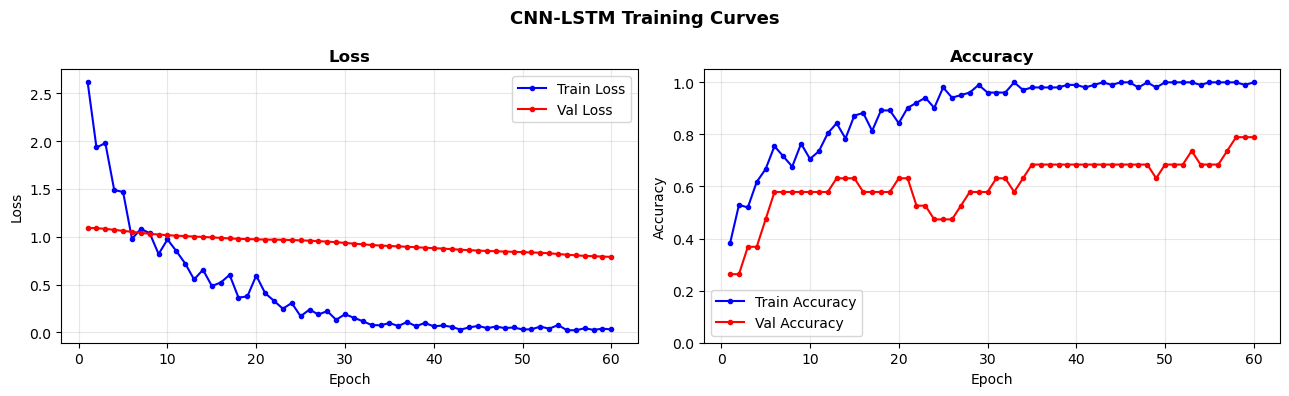

Best epoch      : 60
Best val loss   : 0.7885
Best val acc    : 78.95%


In [6]:
hist = history.history
epochs = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss
axes[0].plot(epochs, hist['loss'],     'b-o', markersize=3, label='Train Loss')
axes[0].plot(epochs, hist['val_loss'], 'r-o', markersize=3, label='Val Loss')
axes[0].set_title("Loss", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, hist['accuracy'],     'b-o', markersize=3, label='Train Accuracy')
axes[1].plot(epochs, hist['val_accuracy'], 'r-o', markersize=3, label='Val Accuracy')
axes[1].set_title("Accuracy", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_ylim([0, 1.05])
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("CNN-LSTM Training Curves", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

best_epoch = np.argmin(hist['val_loss']) + 1
print(f"Best epoch      : {best_epoch}")
print(f"Best val loss   : {min(hist['val_loss']):.4f}")
print(f"Best val acc    : {max(hist['val_accuracy'])*100:.2f}%")

### Save history

In [7]:
with open(f"{OUTPUT_DIR}/training_history.json", 'w') as f:
    json.dump({k: [float(v) for v in vals] for k, vals in hist.items()}, f, indent=2)

print("✅ Saved:")
print("   Model   → outputs/best_model.keras")
print("   History → outputs/training_history.json")

✅ Saved:
   Model   → outputs/best_model.keras
   History → outputs/training_history.json


### ✅ Training Complete

**Model:** CNN-LSTM Hybrid — 92,035 parameters  
**Architecture:** Conv1D × 2 → LSTM × 2 → Dense → Softmax(3)  
**Class weights** ensure AGGRESSIVE & SLOW are not ignored during training

**Next:** `06_Evaluation_Prediction.ipynb`